In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../Dataset/US_Accidents_March23.csv")

In [5]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [6]:
df.shape

(7728394, 46)

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

In [9]:
missing = df.isnull().sum()
missing.sort_values(ascending=False).head(20)

End_Lng                  3402762
End_Lat                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Astronomical_Twilight      23246
Nautical_Twilight          23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
dtype: int64

In [10]:
missing_values = df.isnull().sum()/len(df) * 100
missing_values.sort_values(ascending=False).head(20)

End_Lng                  44.029355
End_Lat                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Sunrise_Sunset            0.300787
Civil_Twilight            0.300787
Astronomical_Twilight     0.300787
Nautical_Twilight         0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
dtype: float64

In [11]:
df = df[
[
'Severity',
'Start_Time',
'Temperature(F)',
'Humidity(%)',
'Visibility(mi)',
'Weather_Condition',
'City',
'State',
'Start_Lat',
'Start_Lng'
]
]

In [12]:
df.head()

,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,Light Rain,Dayton,OH,39.865147,-84.058723
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,Light Rain,Reynoldsburg,OH,39.928059,-82.831184
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,Overcast,Williamsburg,OH,39.063148,-84.032608
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,Mostly Cloudy,Dayton,OH,39.747753,-84.205582
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,Mostly Cloudy,Dayton,OH,39.627781,-84.188354


In [13]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format= 'mixed')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Severity           int64         
 1   Start_Time         datetime64[ns]
 2   Temperature(F)     float64       
 3   Humidity(%)        float64       
 4   Visibility(mi)     float64       
 5   Weather_Condition  str           
 6   City               str           
 7   State              str           
 8   Start_Lat          float64       
 9   Start_Lng          float64       
dtypes: datetime64[ns](1), float64(5), int64(1), str(3)
memory usage: 589.6 MB


In [15]:
df['Hour'] = df['Start_Time'].dt.hour

In [16]:
df['Month'] = df['Start_Time'].dt.month

In [17]:
df['Day'] = df['Start_Time'].dt.day

In [18]:
df.head()

,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,Light Rain,Dayton,OH,39.865147,-84.058723,5,2,8
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,Light Rain,Reynoldsburg,OH,39.928059,-82.831184,6,2,8
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,Overcast,Williamsburg,OH,39.063148,-84.032608,6,2,8
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,Mostly Cloudy,Dayton,OH,39.747753,-84.205582,7,2,8
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,Mostly Cloudy,Dayton,OH,39.627781,-84.188354,7,2,8


In [19]:
df.duplicated().sum()

np.int64(487992)

In [20]:
df.drop_duplicates(inplace=True)

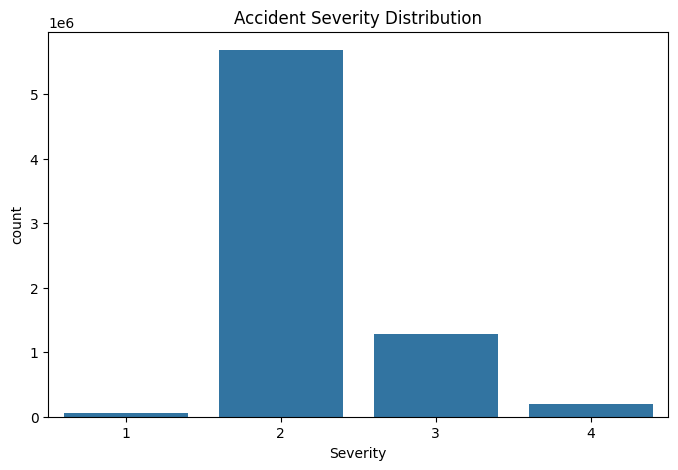

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
x='Severity',
data=df
)

plt.title(
'Accident Severity Distribution'
)

plt.show()

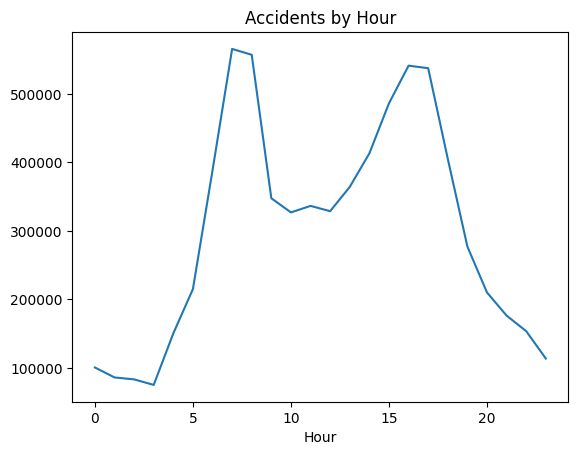

In [22]:
hourly = df['Hour'].value_counts()
hourly.sort_index().plot(kind='line')
plt.title('Accidents by Hour')
plt.show()

In [23]:
df.to_csv("../Dataset/cleaned_accidents.csv", index=False)